# Import Libraries

In [16]:
import warnings
warnings.filterwarnings("ignore")

In [17]:
import sys
from pathlib import Path

# make pygenelab importable from this folder
PYGENELAB_PARENT = Path("/ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/py_scripts")
if str(PYGENELAB_PARENT) not in sys.path:
    sys.path.insert(0, str(PYGENELAB_PARENT))

# auto-reload pygenelab when its .py files change (no need to restart the kernel)
%load_ext autoreload
%autoreload 2

import pygenelab as pgl
import scanpy as sc
import decoupler as dc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
from pathlib import Path
from scipy import sparse
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Load Dataset

In [55]:
# mice dataset path
UPDATED_MICE_DATASET_PATH = "/ix/djishnu/Akanksha/datasets/ERCC1_KO/objects/objects/adata_harmony_v2_re_annot.h5ad"

# load adata
adata = sc.read_h5ad(UPDATED_MICE_DATASET_PATH)

In [56]:
# columns to use
celltype_col = "re_annot"
condition_col = "condition"

# groups to compare
group1 = "WT"
group2 = "KO"

layer = None

In [57]:
cell_types = adata.obs["re_annot"].unique().to_list()
cell_types

['Fast IIX',
 'Fast IIB',
 'NMJ',
 'Fast IIA',
 'MTJ-IIA',
 'FAPs',
 'Pericyte',
 'MTJ-IIX',
 'MTJ-IIB',
 'Macrophages',
 'EC',
 'Skeleton MuSc',
 'Tendon']

In [58]:
SEX = "None"

In [59]:
if SEX == "F" or SEX == "M":
    adata = pgl.subset_adata_by_obs(adata, filters={"sex": SEX})
adata.obs["sex"].value_counts()

sex
M    44171
F    42470
Name: count, dtype: int64

# Calculate Transcriptional Noise

In [60]:
all_noise = []
all_summary = []

for celltype in cell_types:
    print(f"processing: {celltype}")

    # subset one cell type
    adata_ct = adata[
        adata.obs[celltype_col] == celltype
    ].copy()

    # calculate noise
    noise_df, summary = pgl.calculate_noise_one_celltype(
        adata_ct=adata_ct,
        condition_col=condition_col,
        group1=group1,
        group2=group2,
        layer=layer,
        max_cells=500,
        min_cells=10,
        n_bins=10,
        bottom_frac=0.10,
        random_state=1
    )

    # store summary
    summary["celltype"] = celltype
    all_summary.append(summary)

    # store per-cell noise values
    if noise_df is not None:
        noise_df["celltype"] = celltype
        all_noise.append(noise_df)

# combine results
noise_all_df = pd.concat(all_noise, ignore_index=True)
summary_df = pd.DataFrame(all_summary)

# adjust p-values
done_mask = summary_df["status"] == "done"

summary_df.loc[done_mask, "padj"] = multipletests(
    summary_df.loc[done_mask, "pval"],
    method="fdr_bh"
)[1]

summary_df["significant"] = summary_df["padj"] < 0.05

# sort summary
summary_df = summary_df.sort_values(
    f"log2_{group2}_over_{group1}",
    ascending=False,
    na_position="last"
)

summary_df

processing: Fast IIX
processing: Fast IIB
processing: NMJ
processing: Fast IIA
processing: MTJ-IIA
processing: FAPs
processing: Pericyte
processing: MTJ-IIX
processing: MTJ-IIB
processing: Macrophages
processing: EC
processing: Skeleton MuSc
processing: Tendon


,status,n_WT,n_KO,mean_noise_WT,mean_noise_KO,log2_KO_over_WT,pval,n_low_cv_genes,celltype,padj,significant
3,done,500,500,8.633118,8.851048,0.035966,0.014529,210,Fast IIA,0.094436,False
0,done,500,500,8.639334,8.768187,0.021358,0.225283,219,Fast IIX,0.618715,False
4,done,192,192,9.057270,9.140794,0.013243,0.432567,190,MTJ-IIA,0.666857,False
11,done,500,500,13.029381,13.142210,0.012439,0.237925,250,Skeleton MuSc,0.618715,False
5,done,500,500,14.731459,14.817215,0.008374,0.324370,255,FAPs,0.618715,False
10,done,500,500,13.959430,14.024981,0.006759,0.461670,240,EC,0.666857,False
7,done,500,500,8.964143,8.994444,0.004868,0.728447,230,MTJ-IIX,0.739992,False
1,done,500,500,8.698939,8.719619,0.003426,0.564006,220,Fast IIB,0.671807,False
2,done,500,500,9.692012,9.695256,0.000483,0.739992,240,NMJ,0.739992,False
6,done,500,500,13.561487,13.517538,-0.004683,0.568452,240,Pericyte,0.671807,False


# Plot

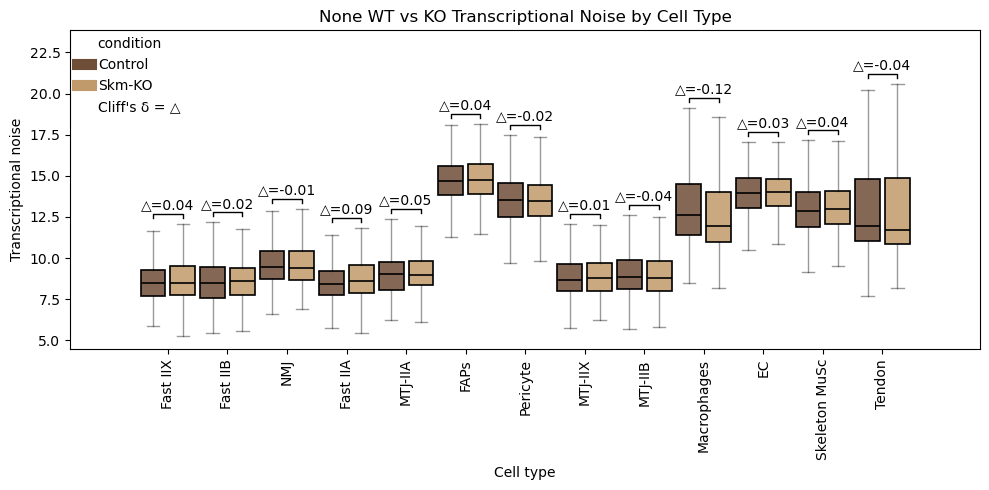

In [69]:
fig, ax = pgl.plot_transcriptional_noise(
    noise_all_df=noise_all_df,
    celltype_order=cell_types,
    group_order=(group1, group2),
    figsize=(10, 5),
    title=f"{SEX} WT vs KO Transcriptional Noise by Cell Type",
    test='mannwhitneyu',
    pvalues=dict(zip(summary_df["celltype"], summary_df["padj"])),
)

plt.show()

# Save Plot

In [70]:
output_dir = Path("Output/Transcriptional_Heterogeneity")
output_dir.mkdir(parents=True, exist_ok=True)

In [71]:
# save plot
svg_path = output_dir / f"{SEX}_WT_vs_KO_Transcriptional_Noise_SVG.svg"
pgl.save_editable_svg(fig, svg_path)

PosixPath('Output/Transcriptional_Heterogeneity/None_WT_vs_KO_Transcriptional_Noise_SVG.svg')

PosixPath('Output/Transcriptional_Heterogeneity/None_WT_vs_KO_Transcriptional_Noise_Stats_SVG.svg')

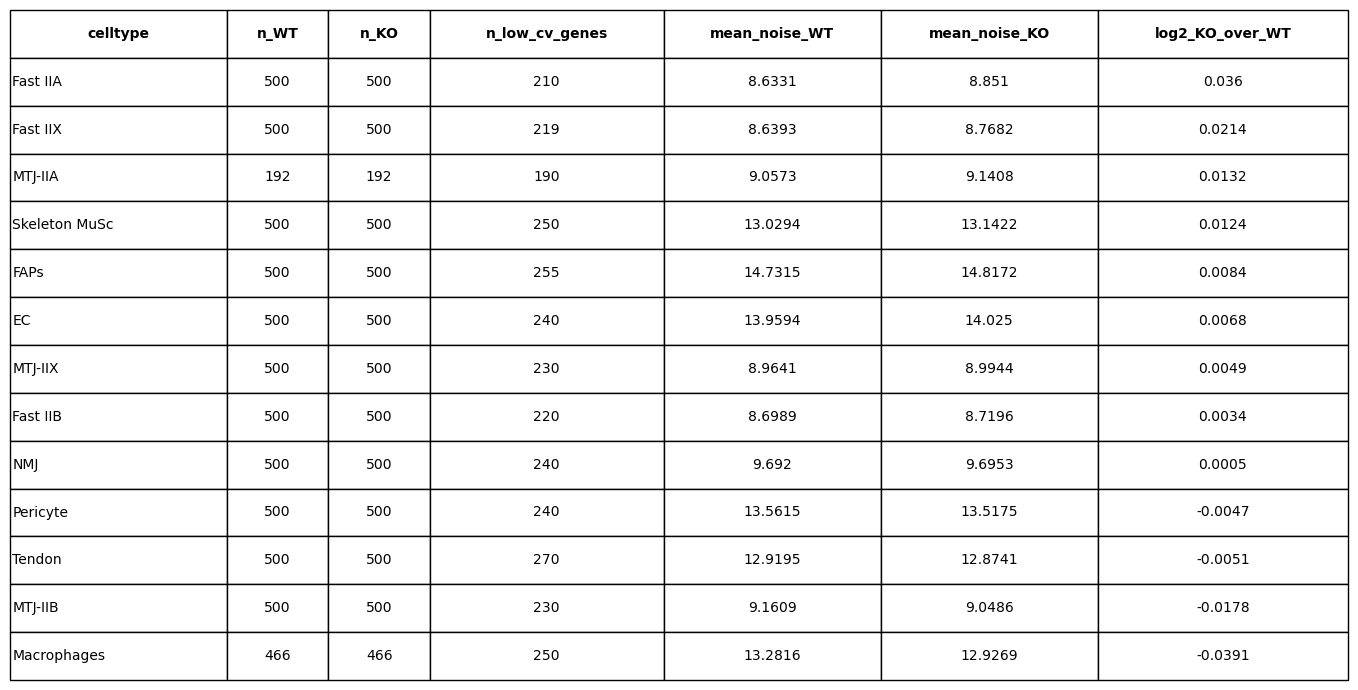

In [72]:
# save stats
stats_df = summary_df[["celltype", "n_WT", "n_KO", "n_low_cv_genes", "mean_noise_WT", "mean_noise_KO", "log2_KO_over_WT"]]
stats_svg_path = output_dir / f"{SEX}_WT_vs_KO_Transcriptional_Noise_Stats_SVG.svg"

stats_fig = pgl.save_df_table_image(stats_df)
pgl.save_editable_svg(stats_fig, stats_svg_path)